# Tu hígado es gelatina. Tu hueso es piedra.

Y entre los dos hay **135.417 veces** de diferencia en rigidez. Ningún pegamento sirve para los dos... hasta que alguien le pidió ayuda a una máquina para diseñar uno a la medida de cada tejido.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

---

**Paper:** *Machine learning-guided design of mechanoadaptive bioglues for multitissue trauma and first-aid applications* — Xuan et al., **Nature Biomedical Engineering** (2026)
**DOI:** [10.1038/s41551-026-01705-8](https://doi.org/10.1038/s41551-026-01705-8)
**Datos:** [Figshare — Source Data oficial](https://doi.org/10.6084/m9.figshare.31769131)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-11-bioglues-ml-multitejido-trauma/notebook.ipynb)

*Video: [Ver en YouTube](https://youtube.com/shorts/sdXqL_-ytzs)*

## El problema: un cuerpo hecho de materiales incompatibles

Una herida real casi nunca toca un solo tejido. Un trauma abdominal mezcla piel, músculo, intestino, hígado. Y cada uno tiene una rigidez radicalmente distinta: el hígado es casi líquido, el hueso es un ladrillo.

Un pegamento médico que funciona en la piel se despega o rompe el tejido si lo usas en el hígado. La idea del equipo: en vez de un pegamento universal, **diseñar uno distinto para cada tejido** — y usar machine learning para encontrar la receta que iguala el régimen mecánico de cada órgano. Lo llamaron **TuneGlues**.

Veamos qué tan lejos llega la idea, con sus propios datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TEJIDO_BLANDO = 'liver'        # El tejido más blando (referencia inferior)
TEJIDO_DURO   = 'cortical bone' # El tejido más rígido (referencia superior)
FUENTE = 'Fuente: Xuan et al. (2026), Nature Biomed. Eng. | Datos: Figshare (Source Data oficial)'
COLOR_DATOS      = '#2563EB'   # Azul CaM — tejido / dato principal
COLOR_ALERTA     = '#DC2626'   # Rojo — TuneGlue / contraste
COLOR_REFERENCIA = '#D97706'   # Amber — umbral / referencia
COLOR_SECUNDARIO = '#059669'   # Emerald — segunda serie

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Nombres de tejido (datos en inglés → español) y formato numérico español
TRAD_TEJIDO = {
    'liver': 'hígado', 'lung': 'pulmón', 'spleen': 'bazo', 'heart': 'corazón',
    'kidney': 'riñón', 'cornea': 'córnea', 'uterus': 'útero', 'muscle': 'músculo',
    'intestine': 'intestino', 'bladder': 'vejiga', 'cartilage': 'cartílago',
    'skin': 'piel', 'cancellous bone': 'hueso esponjoso', 'ligament': 'ligamento',
    'cortical bone': 'hueso cortical', 'bone': 'hueso',
}
def tr(t):
    return TRAD_TEJIDO.get(t, t)

def es(x, dec=0):
    # Formato español: miles con punto, decimales con coma.
    s = f'{x:,.{dec}f}'
    return s.replace(',', '·').replace('.', ',').replace('·', '.')

BASE_REPO = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
BASE_DATA = f'{BASE_REPO}/papers/2026-06-11-bioglues-ml-multitejido-trauma/datos'

# Estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE_REPO}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los 5 CSVs (local datos/ → fallback descarga)
def cargar(nombre):
    ruta = f'datos/{nombre}'
    if not os.path.exists(ruta):
        os.makedirs('datos', exist_ok=True)
        urllib.request.urlretrieve(f'{BASE_DATA}/{nombre}', ruta)
    return pd.read_csv(ruta)

tejidos    = cargar('tejidos_propiedades_mecanicas.csv')
ml_r2      = cargar('ml_validacion_r2.csv')
glue_tej   = cargar('tuneglue_vs_tejido.csv')
adhesion   = cargar('adhesion_por_tejido.csv')
hemostasia = cargar('hemostasia_tiempo.csv')

print(f'{len(tejidos)} tejidos humanos caracterizados')
print(f'Módulo elástico: de {es(tejidos.modulo_elastico_mpa.min(),3)} MPa ({tr(TEJIDO_BLANDO)}) '
      f'a {es(tejidos.modulo_elastico_mpa.max())} MPa ({tr(TEJIDO_DURO)})')
rango = tejidos.modulo_elastico_mpa.max() / tejidos.modulo_elastico_mpa.min()
print(f'Rango dinámico: {es(rango)}x  (~{np.log10(rango):.1f} órdenes de magnitud)')
print(f'TuneGlues evaluados: {[tr(t) for t in sorted(glue_tej.tejido.unique())]}')

15 tejidos humanos caracterizados
Módulo elástico: de 0,012 MPa (hígado) a 1.625 MPa (hueso cortical)
Rango dinámico: 135.417x  (~5.1 órdenes de magnitud)
TuneGlues evaluados: ['hueso', 'intestino', 'hígado', 'pulmón', 'músculo', 'piel']


## El rango es brutal

Antes de pegar nada, hay que entender contra qué se está peleando. Aquí están los 15 tejidos, ordenados por rigidez.

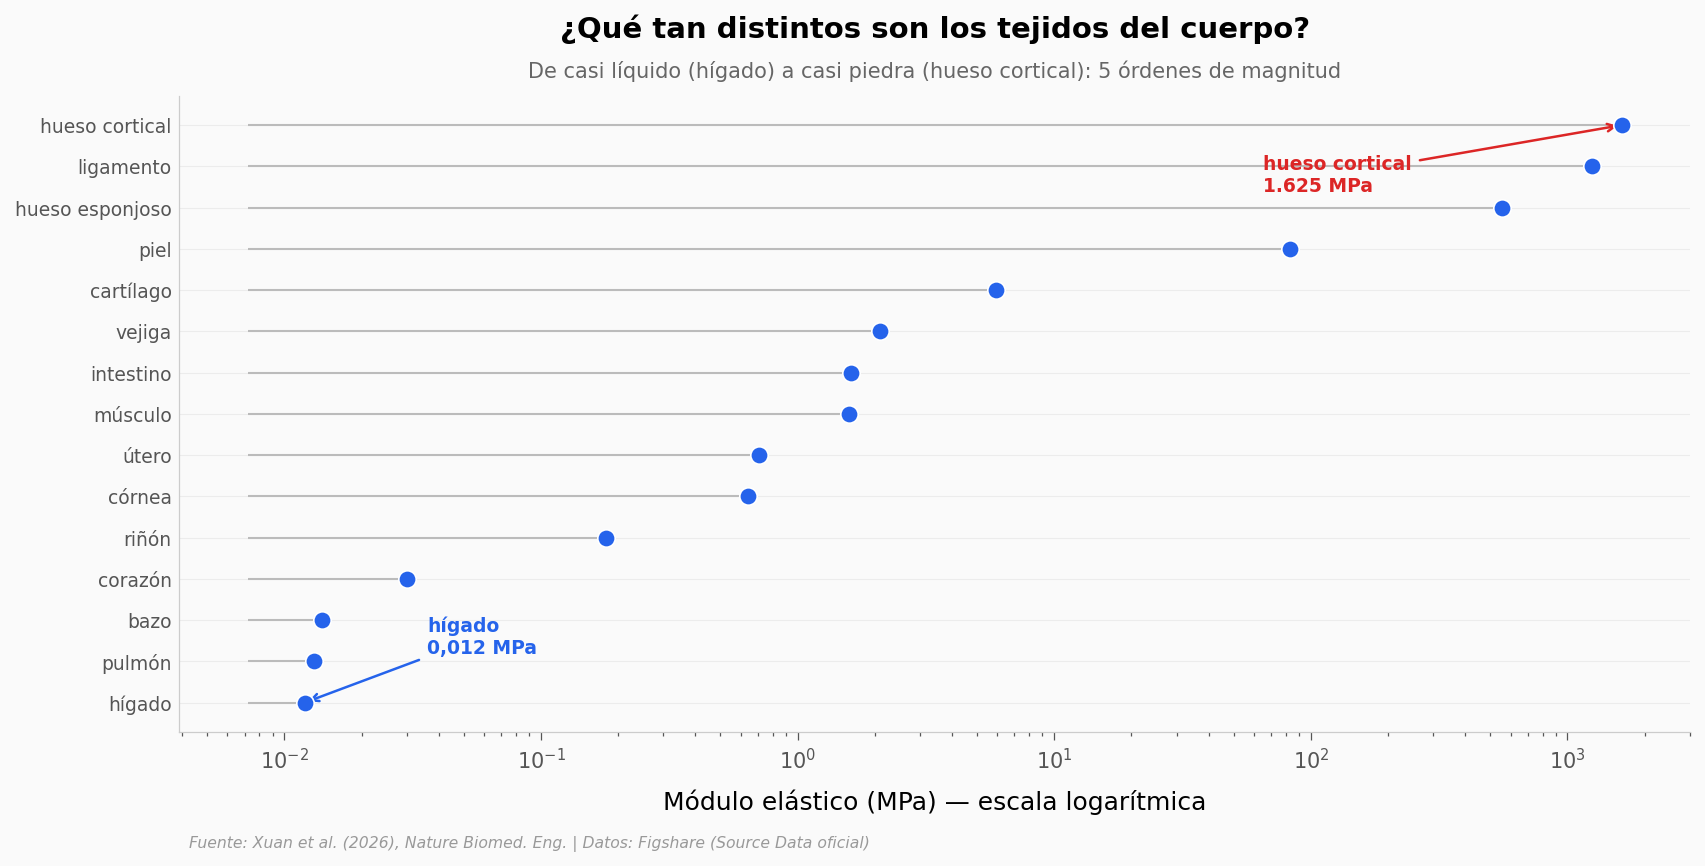

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

orden = tejidos.sort_values('modulo_elastico_mpa')
y = np.arange(len(orden))
ax.hlines(y, tejidos.modulo_elastico_mpa.min()*0.6, orden.modulo_elastico_mpa,
          color='#BBBBBB', linewidth=1.0, zorder=2)
ax.scatter(orden.modulo_elastico_mpa, y, color=COLOR_DATOS, s=70,
           edgecolors='white', linewidths=0.8, zorder=5)

ax.set_xscale('log')
ax.set_yticks(y)
ax.set_yticklabels([tr(t) for t in orden.tejido], fontsize=9)
ax.set_xlabel('Módulo elástico (MPa) — escala logarítmica')
ax.set_title('¿Qué tan distintos son los tejidos del cuerpo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'De casi líquido (hígado) a casi piedra (hueso cortical): 5 órdenes de magnitud',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotar los extremos
blando = orden.iloc[0]; duro = orden.iloc[-1]
ax.annotate(f'{tr(blando.tejido)}\n{es(blando.modulo_elastico_mpa,3)} MPa', xy=(blando.modulo_elastico_mpa, 0),
            xytext=(blando.modulo_elastico_mpa*3, 1.2), fontsize=9, color=COLOR_DATOS, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.2))
ax.annotate(f'{tr(duro.tejido)}\n{es(duro.modulo_elastico_mpa)} MPa', xy=(duro.modulo_elastico_mpa, len(orden)-1),
            xytext=(duro.modulo_elastico_mpa*0.04, len(orden)-2.6), fontsize=9, color=COLOR_ALERTA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.2))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_rango_tejidos.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención no es que el hueso sea duro — eso lo sabíamos. Es la **distancia**: entre el hígado y el hueso cortical hay 135.417 veces de diferencia. Es como pedirle al mismo material que se comporte como gelatina y como concreto.

La mitad blanda (hígado, pulmón, bazo, corazón, riñón) vive por debajo de 1 MPa. La mitad dura (piel, huesos, ligamento) sube de golpe. No hay un punto medio cómodo — por eso un pegamento único fracasa.

## ¿Puede una máquina predecir cómo se comporta un tejido?

Aquí entra el machine learning. El equipo entrenó modelos (bosque aleatorio y red neuronal) para predecir tres propiedades mecánicas del pegamento a partir de su composición. La pregunta honesta: ¿qué tan bien funcionan de verdad?

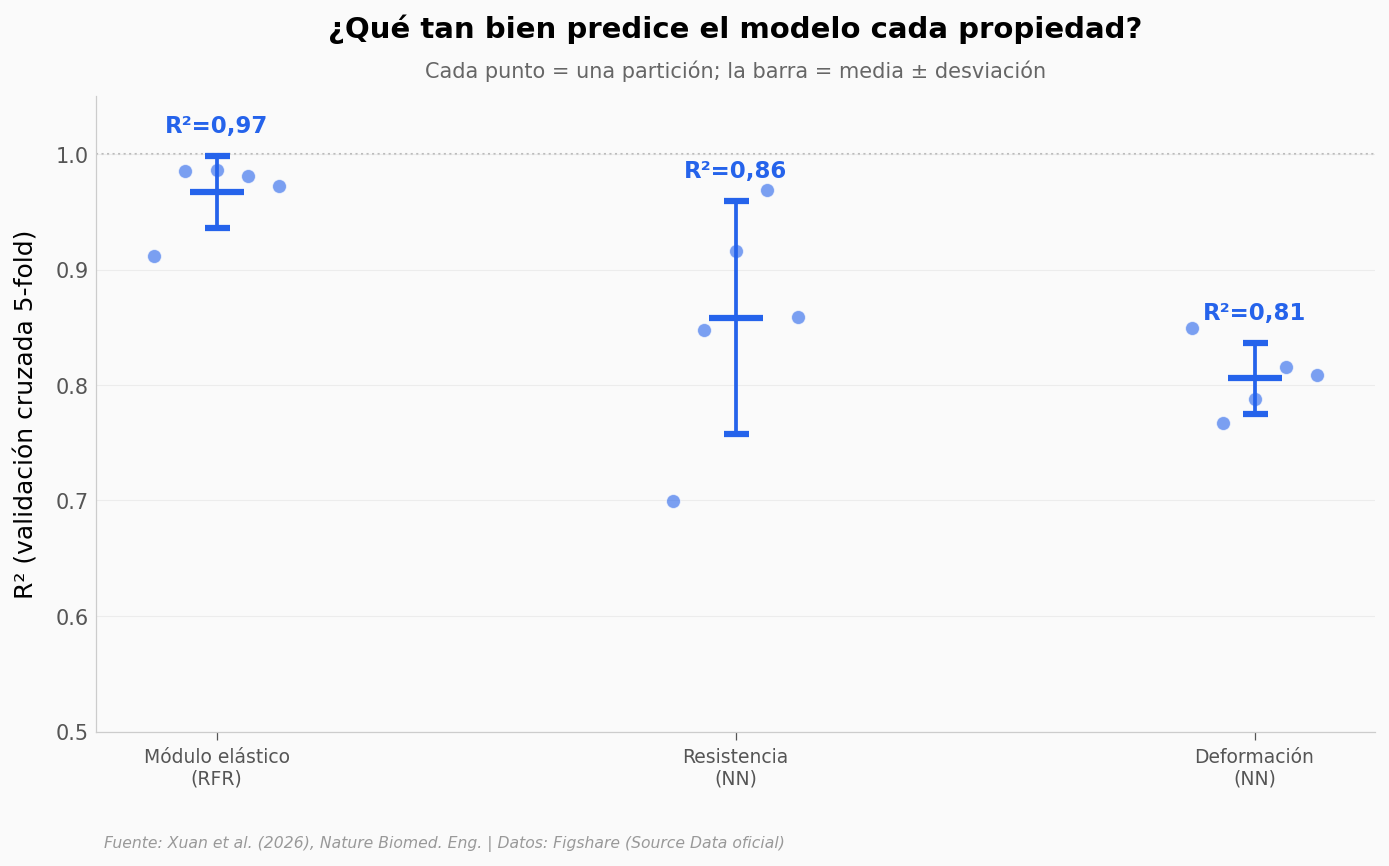

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))

resumen = (ml_r2.groupby(['propiedad', 'modelo'])['r2']
           .agg(['mean', 'std']).reset_index())
# Traduccion de etiquetas
trad = {'Elastic modulus': 'Módulo elástico', 'Tensile Strength': 'Resistencia', 'Deformation': 'Deformación'}
resumen['label'] = resumen['propiedad'].map(trad) + '\n(' + resumen['modelo'] + ')'
resumen = resumen.sort_values('mean', ascending=False).reset_index(drop=True)

x = np.arange(len(resumen))
np.random.seed(42)
for i, row in resumen.iterrows():
    folds = ml_r2[(ml_r2.propiedad == row.propiedad) & (ml_r2.modelo == row.modelo)]['r2'].values
    n = len(folds)
    xs = np.linspace(i - 0.12, i + 0.12, n); np.random.shuffle(xs)
    ax.scatter(xs, folds, color=COLOR_DATOS, s=45, alpha=0.6,
               edgecolors='white', linewidths=0.5, zorder=5)
    ax.errorbar(i, row['mean'], yerr=row['std'], fmt='_', color=COLOR_DATOS,
                markersize=26, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
    ax.text(i, row['mean'] + row['std'] + 0.02, f"R²={es(row['mean'],2)}",
            ha='center', fontsize=11, fontweight='bold', color=COLOR_DATOS)

ax.axhline(1.0, color='#BBBBBB', linewidth=1.0, linestyle=':', zorder=1)
ax.set_xticks(x); ax.set_xticklabels(resumen['label'], fontsize=9)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('R² (validación cruzada 5-fold)')
ax.set_title('¿Qué tan bien predice el modelo cada propiedad?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto = una partición; la barra = media ± desviación',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ml_r2.png', dpi=200, bbox_inches='tight')
plt.show()

El módulo elástico lo clava (R²=0,97): el modelo casi lee la mente del material. Resistencia y deformación bajan a 0,86 y 0,81 — buenos, pero con más dispersión entre particiones. Tiene sentido: predecir cuánto se estira algo antes de romperse es más ruidoso que predecir su rigidez.

Pero predecir bien no es lo mismo que **acertarle al tejido real**. ¿El pegamento diseñado de verdad cae en el régimen mecánico de su órgano?

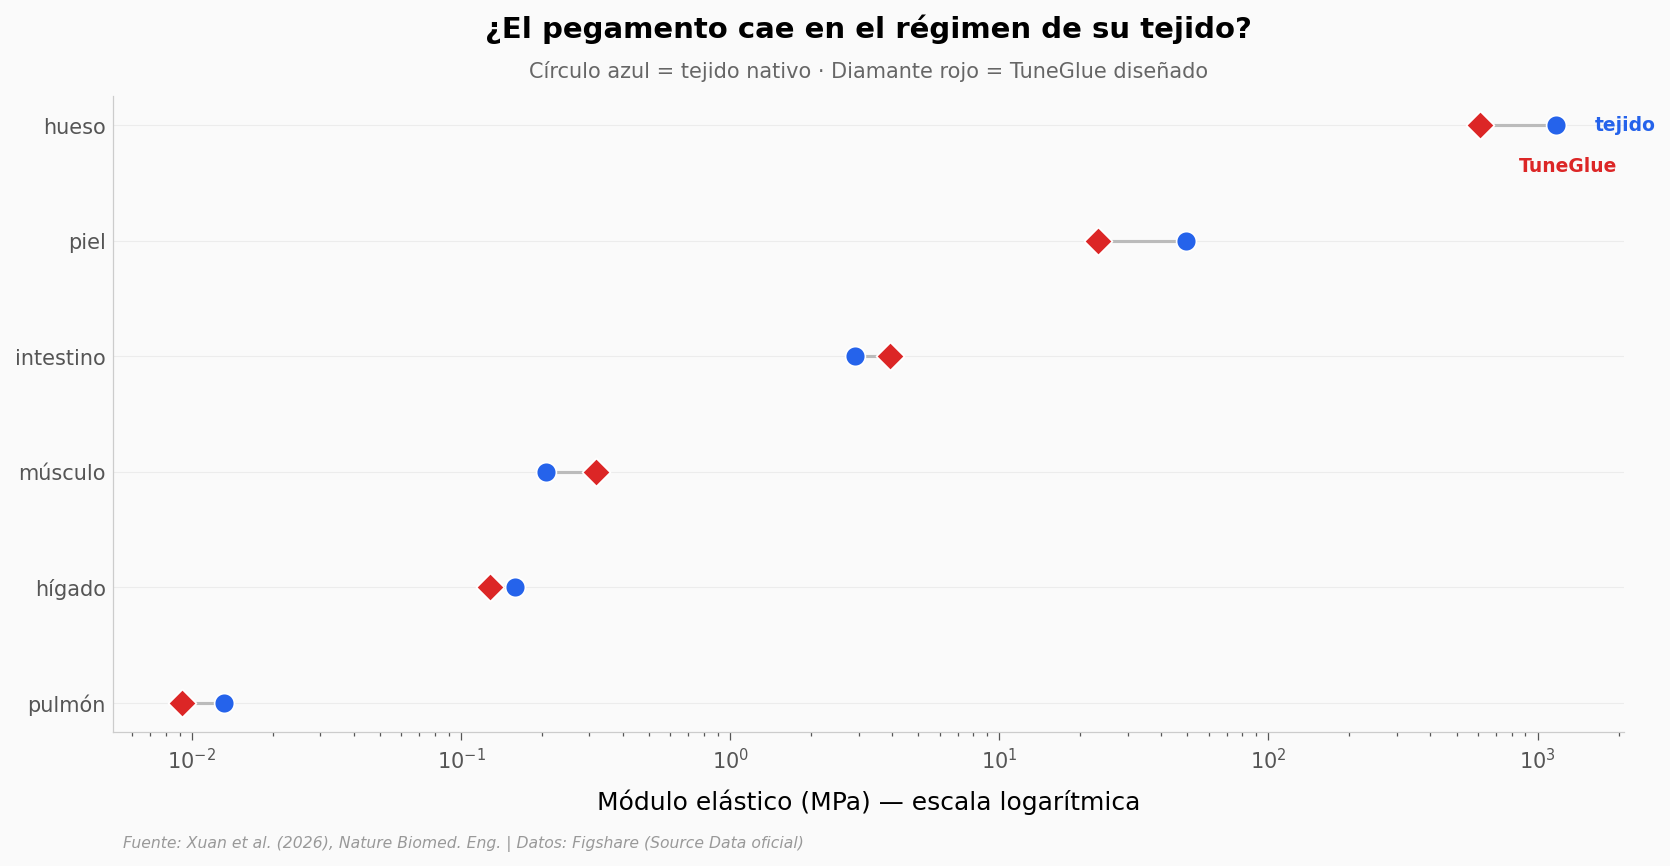

Ratio TuneGlue/tejido (módulo elástico):
  piel          : 0,47x
  hueso         : 0,52x
  pulmón        : 0,69x
  hígado        : 0,81x
  intestino     : 1,34x
  músculo       : 1,54x


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

me = glue_tej[glue_tej.propiedad == 'modulo_elastico_mpa']
piv = me.groupby(['tejido', 'material']).valor.mean().unstack()
piv = piv.sort_values('tejido_nativo')

ypos = np.arange(len(piv))
for i, (tej, row) in enumerate(piv.iterrows()):
    ax.plot([row['tejido_nativo'], row['tuneglue']], [i, i],
            color='#BBBBBB', linewidth=1.5, zorder=2)
ax.scatter(piv['tejido_nativo'], ypos, color=COLOR_DATOS, s=90,
           edgecolors='white', linewidths=0.8, zorder=5)
ax.scatter(piv['tuneglue'], ypos, color=COLOR_ALERTA, s=90, marker='D',
           edgecolors='white', linewidths=0.8, zorder=5)

ax.set_xscale('log')
ax.set_yticks(ypos); ax.set_yticklabels([tr(t) for t in piv.index], fontsize=10)
ax.set_xlabel('Módulo elástico (MPa) — escala logarítmica')
ax.set_title('¿El pegamento cae en el régimen de su tejido?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Círculo azul = tejido nativo · Diamante rojo = TuneGlue diseñado',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
# Inline labels en lugar de legend box
ax.text(piv['tejido_nativo'].iloc[-1]*1.4, ypos[-1], 'tejido', fontsize=9,
        color=COLOR_DATOS, fontweight='bold', va='center')
ax.text(piv['tuneglue'].iloc[-1]*1.4, ypos[-1]-0.35, 'TuneGlue', fontsize=9,
        color=COLOR_ALERTA, fontweight='bold', va='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/glue_vs_tejido.png', dpi=200, bbox_inches='tight')
plt.show()

# Ratios glue/tejido para la lectura
piv['ratio'] = piv['tuneglue'] / piv['tejido_nativo']
print('Ratio TuneGlue/tejido (módulo elástico):')
for tej, row in piv.sort_values('ratio').iterrows():
    print(f'  {tr(tej):14s}: {es(row.ratio,2)}x')

Cada diamante rojo aterriza pegado a su círculo azul, **a lo largo de 5 órdenes de magnitud**. Los ratios van de 0,47 (piel — el más flojo, el pegamento queda ~2,1x más blando) a 1,54 (músculo). Es decir: cinco de seis pegamentos caen dentro de ~2x del tejido real.

Importante no exagerar: esto es un match de **régimen mecánico**, no exacto. El pegamento no "iguala" al tejido — cae en su mismo vecindario, que ya es muchísimo para un material sintético. ¿Y cómo se ve eso contra toda la distribución de rigideces del cuerpo?

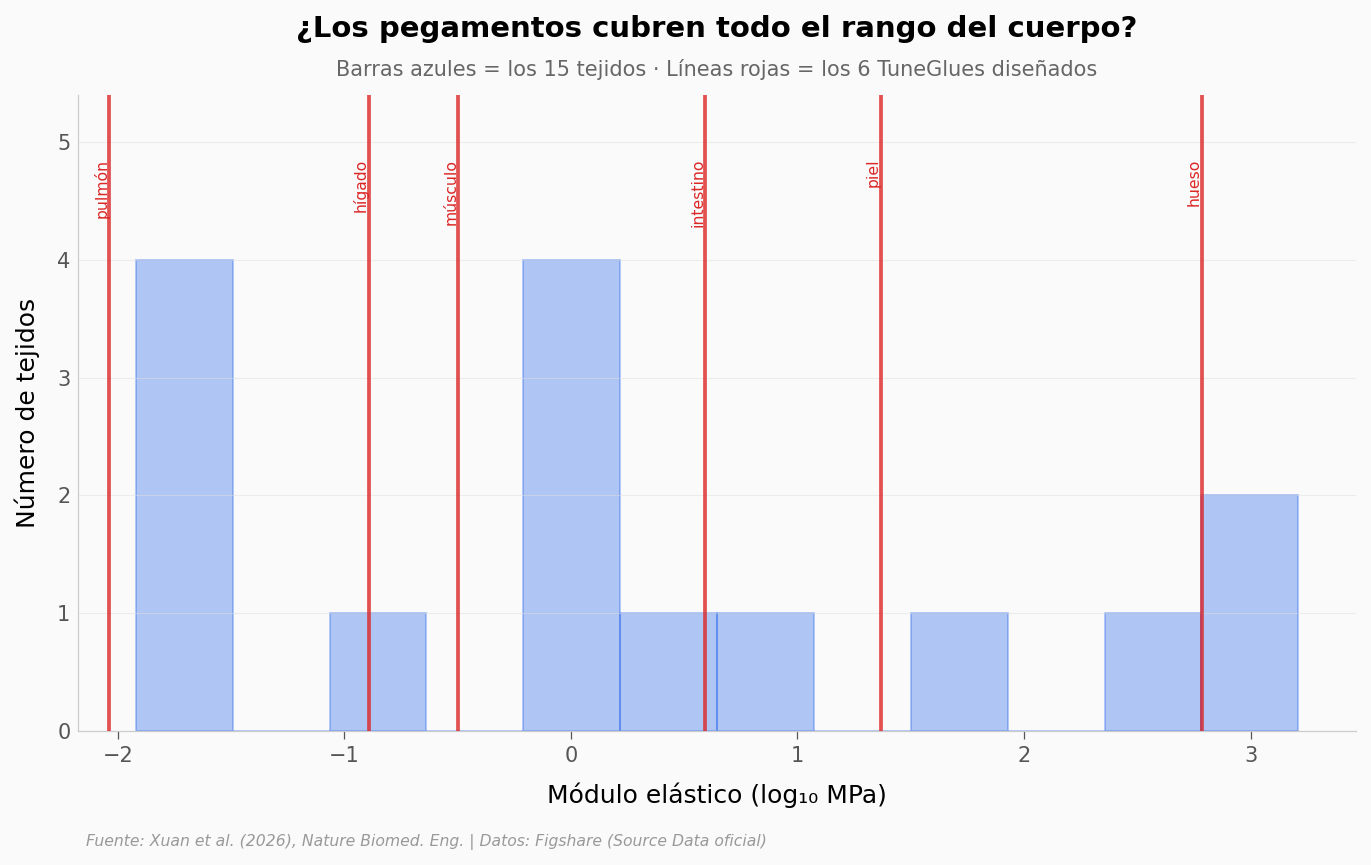

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

logmods = np.log10(tejidos.modulo_elastico_mpa.values)
n, bins, patches = ax.hist(logmods, bins=12, color=COLOR_DATOS, alpha=0.35,
                           edgecolor=COLOR_DATOS, linewidth=0.9)
y_max = n.max() * 1.35
ax.set_ylim(0, y_max)

# Marcar donde cae cada TuneGlue disenado (modulo elastico medio)
glues = piv['tuneglue']
for tej, val in glues.items():
    ax.axvline(np.log10(val), color=COLOR_ALERTA, linewidth=1.8, alpha=0.8, zorder=4)
    ax.text(np.log10(val), y_max*0.9, tr(tej), rotation=90, fontsize=7.5,
            color=COLOR_ALERTA, ha='right', va='top')

ax.set_xlabel('Módulo elástico (log₁₀ MPa)')
ax.set_ylabel('Número de tejidos')
ax.set_title('¿Los pegamentos cubren todo el rango del cuerpo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Barras azules = los 15 tejidos · Líneas rojas = los 6 TuneGlues diseñados',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cobertura_rango.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que importa al final: ¿para una herida real?

Diseñar un material elegante está bien, pero la prueba real es si **detiene un sangrado**. Veamos el tiempo de hemostasia —cuánto tarda en parar la sangre— en un modelo animal de hígado lesionado.

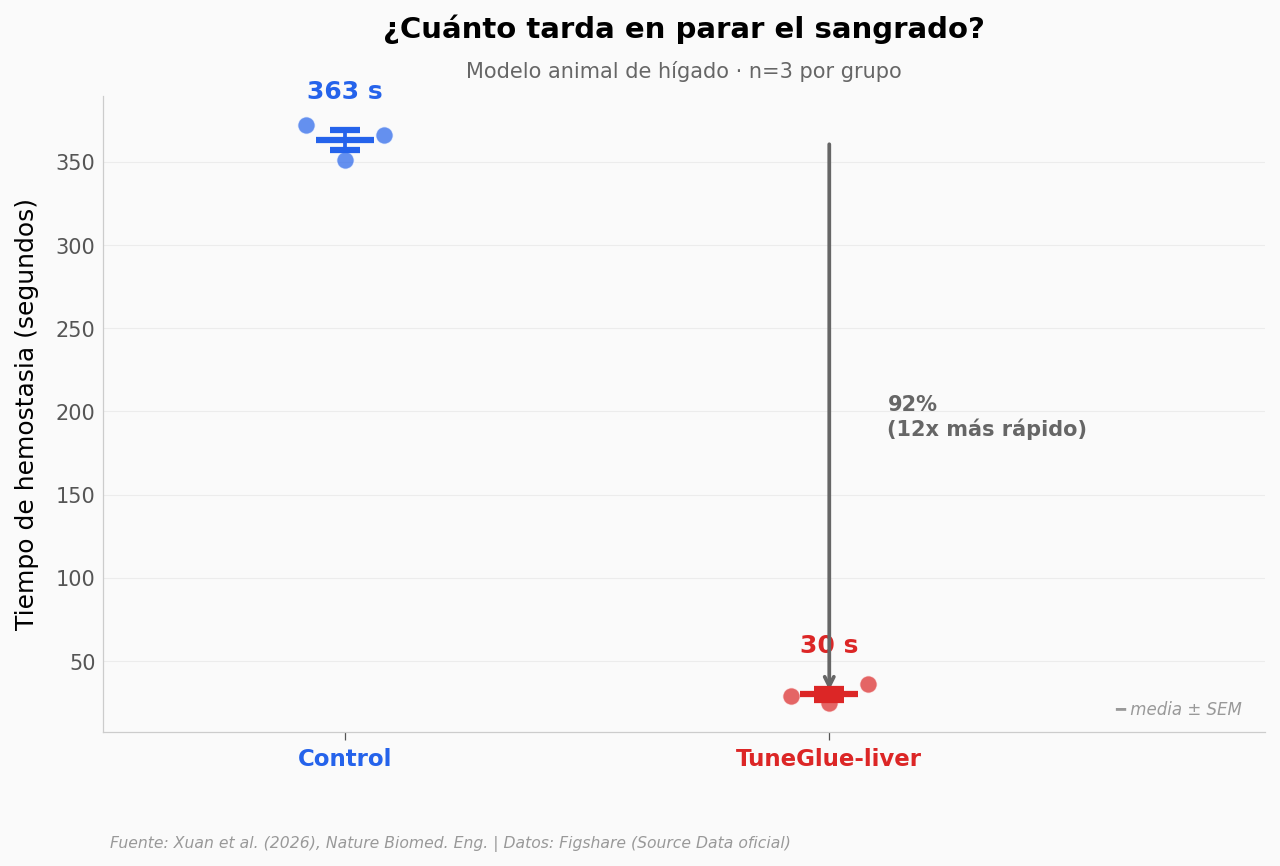

Control: 363 s  →  TuneGlue: 30 s
Mann-Whitney U=9, p=0,10  (n=3 vs 3 — ver nota en la tabla)


In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))

grupos = [('Control', hemostasia[hemostasia.grupo == 'control'].tiempo_s.values, COLOR_DATOS),
          ('TuneGlue-liver', hemostasia[hemostasia.grupo == 'tuneglue_liver'].tiempo_s.values, COLOR_ALERTA)]
positions = [0, 1]
np.random.seed(42)
for i, (nombre, vals, color) in enumerate(grupos):
    nrep = len(vals)
    xs = np.linspace(positions[i] - 0.08, positions[i] + 0.08, nrep); np.random.shuffle(xs)
    ax.scatter(xs, vals, color=color, s=70, alpha=0.7,
               edgecolors='white', linewidths=0.6, zorder=5)
    m = vals.mean(); sem = vals.std(ddof=1) / np.sqrt(nrep)
    ax.errorbar(positions[i], m, yerr=sem, fmt='_', color=color,
                markersize=28, markeredgewidth=3, capsize=7, capthick=1.5, zorder=6)
    ax.text(positions[i], m + 25, f'{m:.0f} s', ha='center',
            fontsize=12, fontweight='bold', color=color)

c_mean = grupos[0][1].mean(); t_mean = grupos[1][1].mean()
ax.annotate('', xy=(1, t_mean), xytext=(1, c_mean),
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.8))
ax.text(1.12, (c_mean + t_mean) / 2,
        f'{(c_mean-t_mean)/c_mean*100:.0f}%\n({c_mean/t_mean:.0f}x más rápido)',
        fontsize=10, color='#666666', va='center', fontweight='bold')

ax.set_xticks(positions); ax.set_xticklabels(['Control', 'TuneGlue-liver'], fontsize=11, fontweight='bold')
ax.get_xticklabels()[0].set_color(COLOR_DATOS); ax.get_xticklabels()[1].set_color(COLOR_ALERTA)
ax.set_xlim(-0.5, 1.9)
ax.set_ylabel('Tiempo de hemostasia (segundos)')
ax.set_title('¿Cuánto tarda en parar el sangrado?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Modelo animal de hígado · n=3 por grupo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hemostasia.png', dpi=200, bbox_inches='tight')
plt.show()

u, p = stats.mannwhitneyu(grupos[0][1], grupos[1][1], alternative='two-sided')
print(f'Control: {c_mean:.0f} s  →  TuneGlue: {t_mean:.0f} s')
print(f'Mann-Whitney U={u:.0f}, p={es(p,2)}  (n=3 vs 3 — ver nota en la tabla)')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los 15 tejidos abarcan 5 órdenes de magnitud en rigidez | ✅ | Hígado 0,012 MPa → hueso cortical 1.625 MPa = 135.417x. Lectura directa del Source Data |
| El ML predice el módulo elástico con alta precisión | ✅ | R²=0,97 (5-fold CV, bosque aleatorio). Resistencia 0,86 y deformación 0,81: buenos con más dispersión |
| Cada TuneGlue cae en el régimen mecánico de su tejido | ⚠️ | 5/6 dentro de ~2x; piel es el más flojo (2,1x más blando). Match de régimen, NO exacto |
| TuneGlue-liver acelera la hemostasia ~12x | ⚠️ | 363 s → 30 s (−92%) en modelo animal. Efecto enorme, pero **n=3 vs 3**: p=0,10 es el mínimo posible con ese n, no es significancia estadística |

> **Limitaciones:** Todos los resultados in vivo (adhesión, hemostasia, cicatrización) son en **modelos animales**, no en humanos ni en clínica. La hemostasia tiene n=3 por grupo — muestra la dirección y magnitud, no prueba estadística. El "match" tejido-pegamento es de orden de magnitud, no exacto. Los autores enmarcan la plataforma como *prometedora*, no como tecnología clínica probada.

## Ahora tú

Los datos están cargados. Tres preguntas para explorar:

1. **¿Cuál TuneGlue tiene el peor match?** Calcula el ratio `tuneglue/tejido_nativo` para la *resistencia* (no solo el módulo) y compáralo con el del módulo elástico. ¿El mismo tejido es el más difícil en ambas propiedades?
   *Pista:* filtra `glue_tej` por `propiedad == 'resistencia_mpa'`.

2. **¿La adhesión sigue la rigidez del tejido?** Cruza `adhesion` (kPa por TuneGlue) con `tejidos` (módulo elástico). ¿El pegamento del hueso pega 580x más que el del pulmón porque el hueso es más rígido?
   *Pista:* une por nombre de tejido y grafica adhesión vs módulo en escala log-log.

3. **¿Qué pasa con la deformación?** Es la propiedad con menor R² (0,81). Mira la dispersión entre particiones en `ml_r2` — ¿por qué cuesta más predecirla?

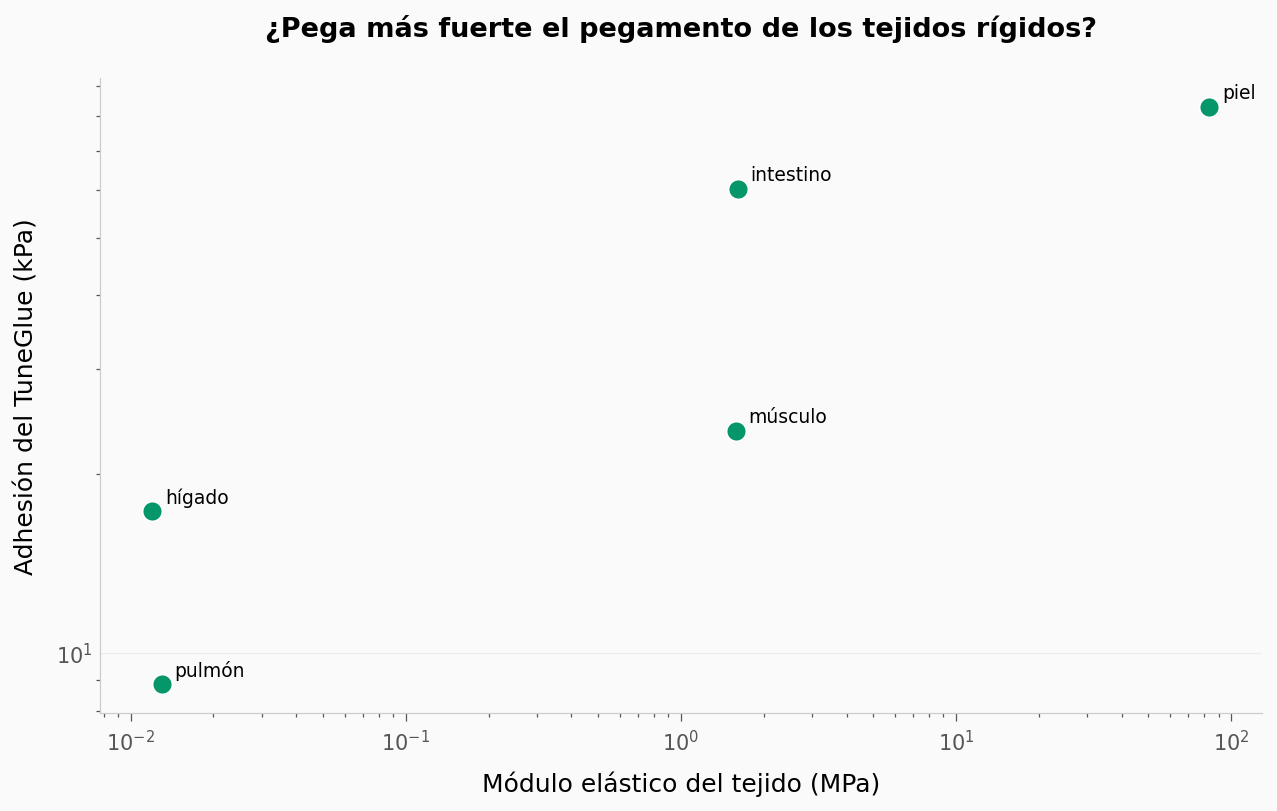

Correlación de Spearman (rigidez vs adhesión): rho=0,90, p=0,037, n=5


In [7]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿la adhesión sigue la rigidez del tejido?
adh_media = adhesion.groupby('tuneglue').adhesion_kpa.mean()
mod_tejido = tejidos.set_index('tejido').modulo_elastico_mpa

cruce = pd.DataFrame({'adhesion_kpa': adh_media}).join(
    mod_tejido.rename('modulo_mpa'), how='inner')

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(cruce.modulo_mpa, cruce.adhesion_kpa, color=COLOR_SECUNDARIO,
           s=90, edgecolors='white', linewidths=0.8, zorder=5)
for tej, row in cruce.iterrows():
    ax.annotate(tr(tej), (row.modulo_mpa, row.adhesion_kpa),
                fontsize=9, xytext=(6, 4), textcoords='offset points')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Módulo elástico del tejido (MPa)')
ax.set_ylabel('Adhesión del TuneGlue (kPa)')
ax.set_title('¿Pega más fuerte el pegamento de los tejidos rígidos?',
             fontsize=13, fontweight='bold', pad=20)
plt.show()

rho, pval = stats.spearmanr(cruce.modulo_mpa, cruce.adhesion_kpa)
print(f'Correlación de Spearman (rigidez vs adhesión): rho={es(rho,2)}, p={es(pval,3)}, n={len(cruce)}')

---

## Fuentes

**Paper**: [Machine learning-guided design of mechanoadaptive bioglues for multitissue trauma and first-aid applications](https://doi.org/10.1038/s41551-026-01705-8)  
*Nature Biomedical Engineering, 2026-06-11 · paywall*

**Dataset canónico**: [Dataset for "Machine Learning-Guided Design of Mechanoadaptive Bioglues for Multi-Tissue Trauma and First-Aid Applications"](https://doi.org/10.6084/m9.figshare.31769131)  
*Figshare — Source Data oficial (mismo DOI): propiedades mecánicas de 15 tejidos, validación ML 5-fold, comparación TuneGlue–tejido, adhesión y hemostasia*

*15 afirmaciones verificadas contra estas fuentes*